In [7]:
import numpy as np
import json
from matplotlib import pyplot as plt
from pathlib import Path

from utils.general_functions import complex_to_mag_db_ph_deg, transfer_function, generate_masks

In [8]:
N = 512
freq_lim = [10.0, 100e3]

freq = np.linspace(freq_lim[0], freq_lim[-1], N)

gain_complex = transfer_function(
    freq=freq,
    zero_poles=int(0),
    poles=[],
    zeros=[10e3]
)

In [9]:
user_figsize = (12, 8)
user_fontsize = 14
user_ylabel = ['Magnitude, dB', 'Phase, deg']

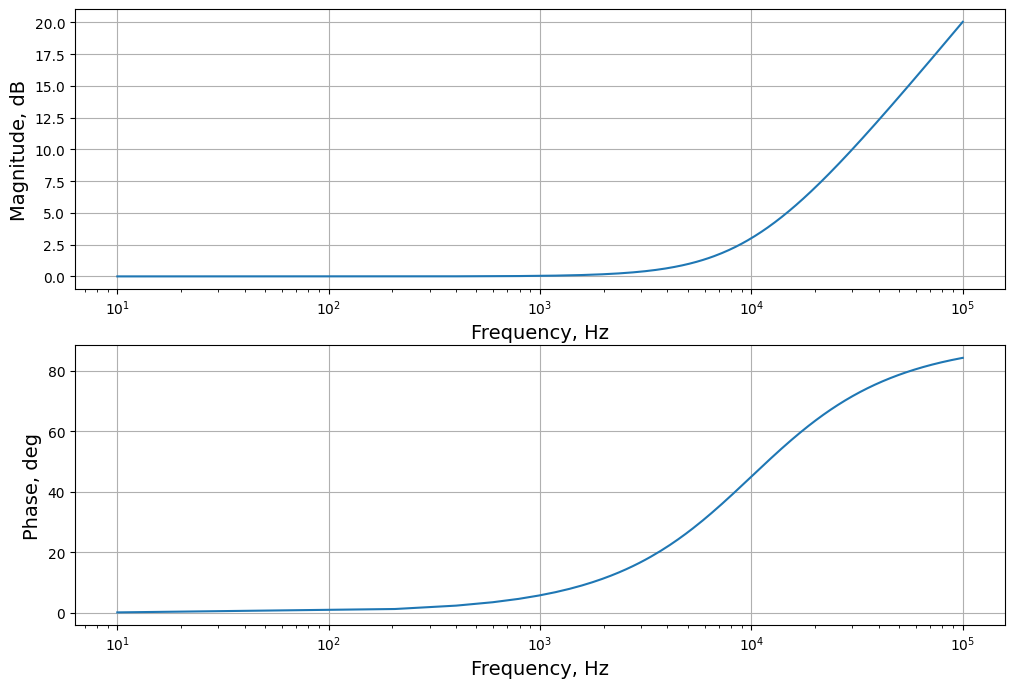

In [10]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=user_figsize)
mag_ph_dataset = complex_to_mag_db_ph_deg(gain_complex)

for idx, ax in enumerate(axs):
    ax.plot(np.linspace(freq_lim[0], freq_lim[-1], N), mag_ph_dataset[idx])
    ax.set_xlabel('Frequency, Hz', fontsize=user_fontsize)
    ax.set_ylabel(user_ylabel[idx], fontsize=user_fontsize)
    ax.axes.grid(True)
    ax.set_xscale('log')
plt.show()

In [ ]:
config_dir = Path("./config/")
dataset_dir = Path('./dataset/')

In [43]:
config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    configer = json.load(f)

masks = generate_masks(masks={}, configer=configer)
print(masks["1zp2lp1rp2lz1rz_001"])

{'zero_poles': 1, 'left_poles': [163, 117], 'right_poles': [409], 'left_zeros': [423, 170], 'right_zeros': [347]}
